
> Coffe Sales Dataset



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Coffe_sales.csv')

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Display the first few rows of the dataset
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Get a summary of the dataset
print(df.describe())

  cash_type  money    coffee_name Time_of_Day Weekday Month_name  Weekdaysort  \
0      card   38.7          Latte     Morning     Fri        Mar            5   
1      card   38.7  Hot Chocolate   Afternoon     Fri        Mar            5   
2      card   38.7  Hot Chocolate   Afternoon     Fri        Mar            5   
3      card   28.9      Americano   Afternoon     Fri        Mar            5   
4      card   38.7          Latte   Afternoon     Fri        Mar            5   

        Date  
0 2024-03-01  
1 2024-03-01  
2 2024-03-01  
3 2024-03-01  
4 2024-03-01  
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Date           0
dtype: int64
             money  Weekdaysort                           Date
count  3547.000000  3547.000000                           3547
mean     31.645216     3.845785  2024-10-04 17:34:43.676346368
min      18.120000     1.000000            2024-03-01 00:00:00
25%      27.920000    

**Feature Engineering**

 ***Date-Time Features***

In [ ]:
# Extracting features from the Date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday  # Monday=0, Sunday=6

In [ ]:
# Group by Date and Time_of_Day to get total sales
daily_sales = df.groupby(['Date', 'Time_of_Day'])['money'].sum().reset_index()

***Lag Features***

In [ ]:
# Creating lag features
daily_sales['Lag_1'] = daily_sales['money'].shift(1)
daily_sales['Lag_2'] = daily_sales['money'].shift(2)
daily_sales['Lag_7'] = daily_sales['money'].shift(7)

**Exploratory Time Series Visualization**

**1- Line Plot of Daily Sales:**

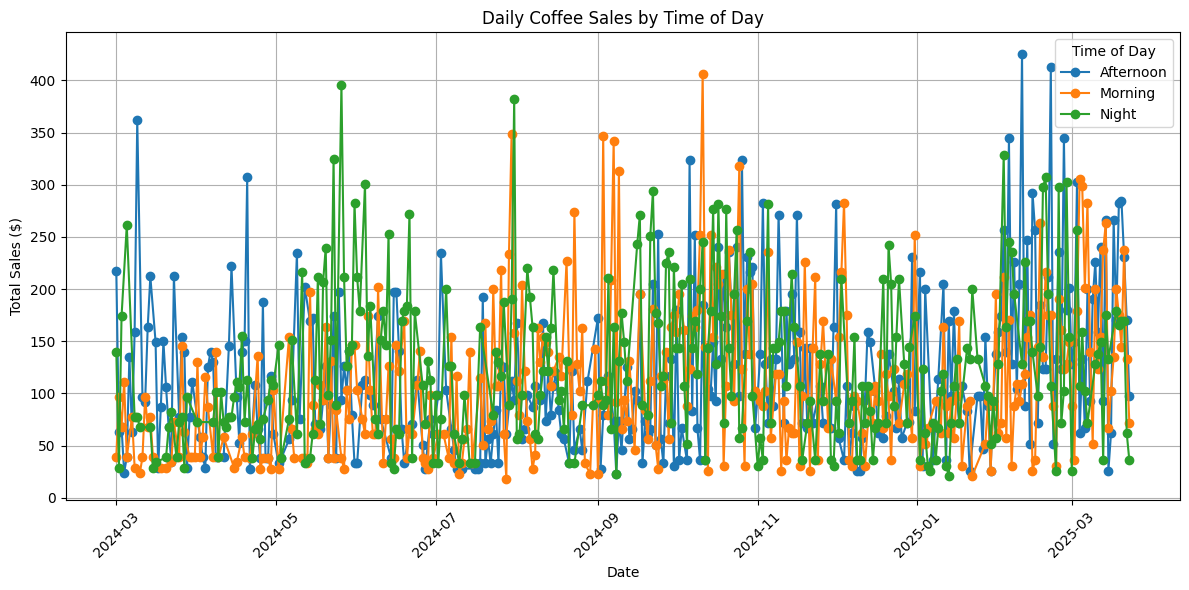

In [ ]:
plt.figure(figsize=(12, 6))
for time in daily_sales['Time_of_Day'].unique():
    subset = daily_sales[daily_sales['Time_of_Day'] == time]
    plt.plot(subset['Date'], subset['money'], marker='o', label=time)

plt.title('Daily Coffee Sales by Time of Day')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.legend(title='Time of Day')
plt.grid()
plt.tight_layout()
plt.show()

2- Autocorrelation and Partial Autocorrelation Plots:




<Figure size 1200x600 with 0 Axes>

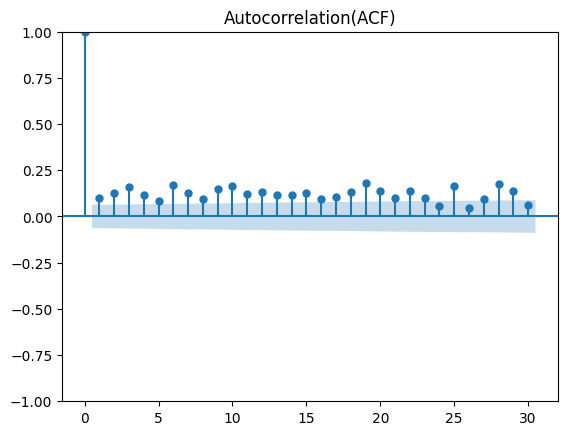

<Figure size 1200x600 with 0 Axes>

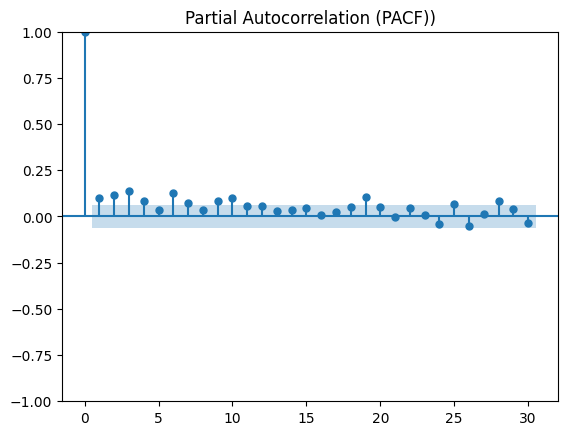

In [ ]:
plt.figure(figsize=(12, 6))
plot_acf(daily_sales['money'], lags=30)
plt.title('Autocorrelation(ACF)')
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(daily_sales['money'], lags=30)
plt.title('Partial Autocorrelation (PACF))')
plt.show()



**3- Histogram  Plot**

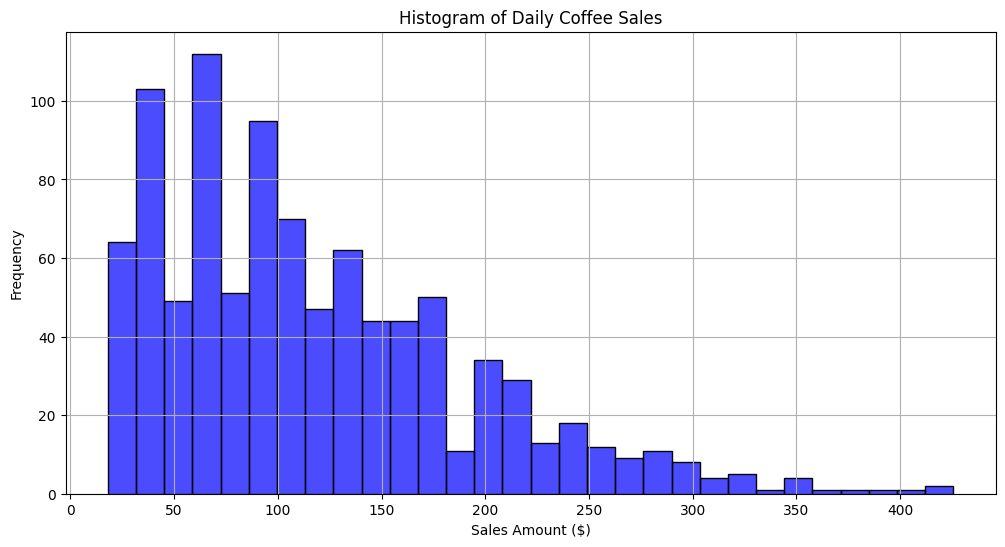

In [ ]:
# Set up the figure
plt.figure(figsize=(12, 6))

# Histogram
sns.histplot(daily_sales['money'], bins=30, kde=False, color='blue', alpha=0.7)
plt.title('Histogram of Daily Coffee Sales')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Frequency')
plt.grid()
plt.show()



**4- Density Plot**

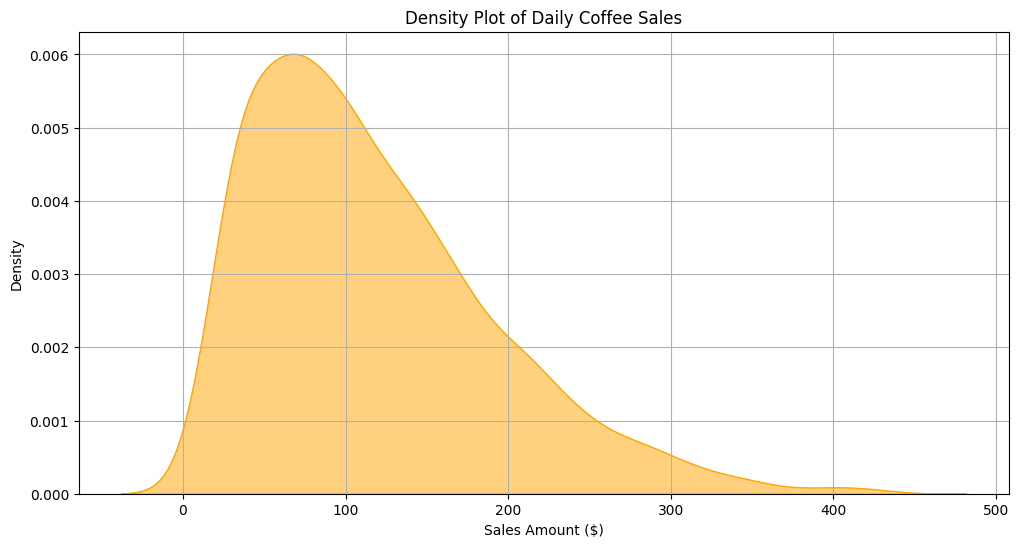

In [ ]:
# Density Plot
plt.figure(figsize=(12, 6))
sns.kdeplot(daily_sales['money'], color='orange', fill=True, alpha=0.5)
plt.title('Density Plot of Daily Coffee Sales')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Density')
plt.grid()
plt.show()

**White Noise الضوضاء البيضاء**

count    1000.000000
mean       -0.013222
std         1.003685
min        -2.961214
25%        -0.684192
50%        -0.010934
75%         0.703915
max         2.737260
dtype: float64


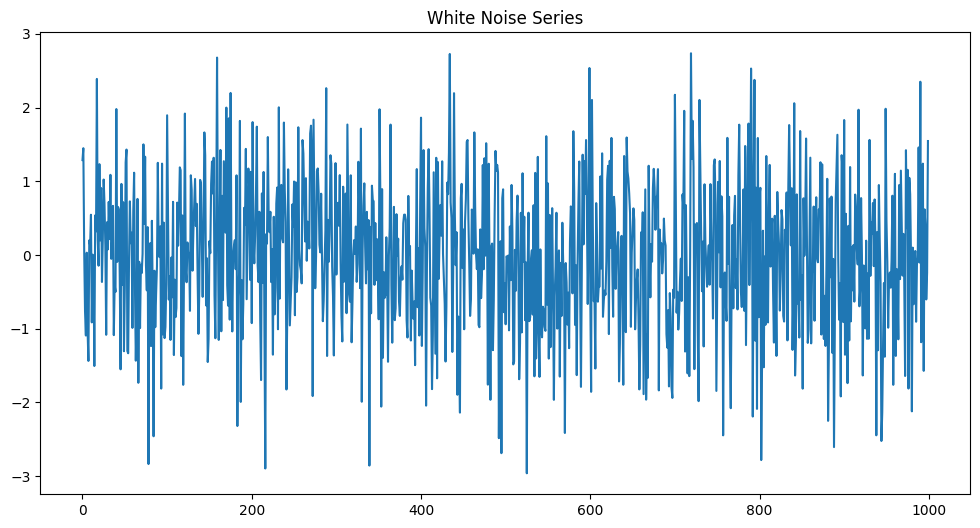

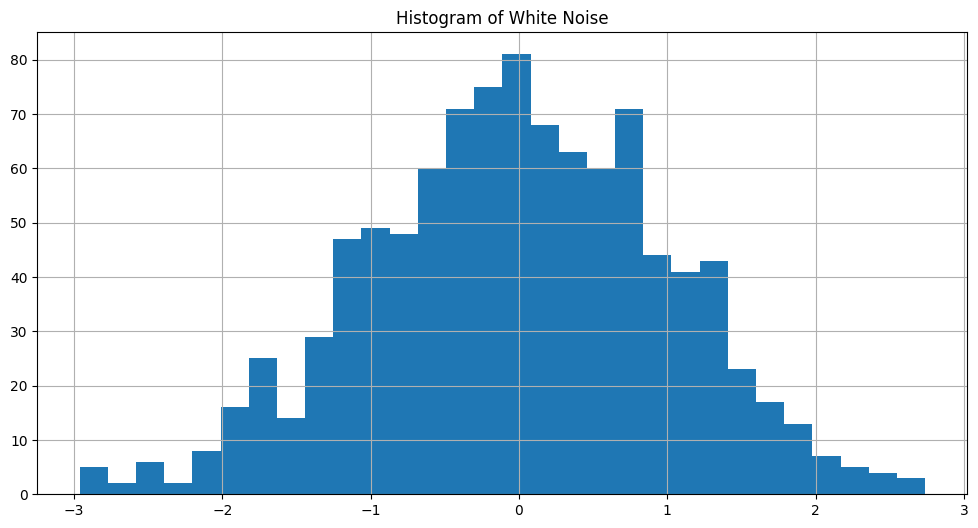

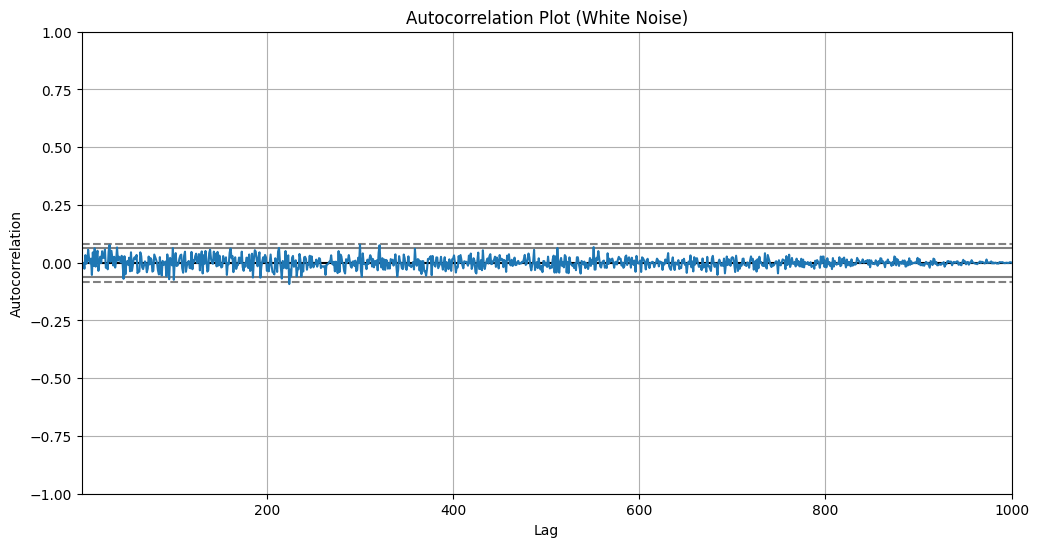

In [ ]:
import pandas as pd
import numpy as np
from random import gauss, seed
from pandas import Series
from pandas.plotting import autocorrelation_plot
from matplotlib import pyplot as plt

# 1. تثبيت العشوائية
seed(1)

# إنشاء سلسلة العشوائية (White Noise)
n = 1000  # عدد النقاط
series = [gauss(0.0, 1.0) for i in range(n)]
series = Series(series)

# الإحصاءات
print(series.describe())

# الرسم الخطي
plt.figure(figsize=(12, 6))
series.plot(title='White Noise Series')
plt.show()

# الرسم التكراري
plt.figure(figsize=(12, 6))
series.hist(bins=30)
plt.title('Histogram of White Noise')
plt.show()

# الارتباط الذاتي
plt.figure(figsize=(12, 6))
autocorrelation_plot(series)
plt.title('Autocorrelation Plot (White Noise)')
plt.show()

**Box-Cox Transformation**

Minimum value in the data: 0.0


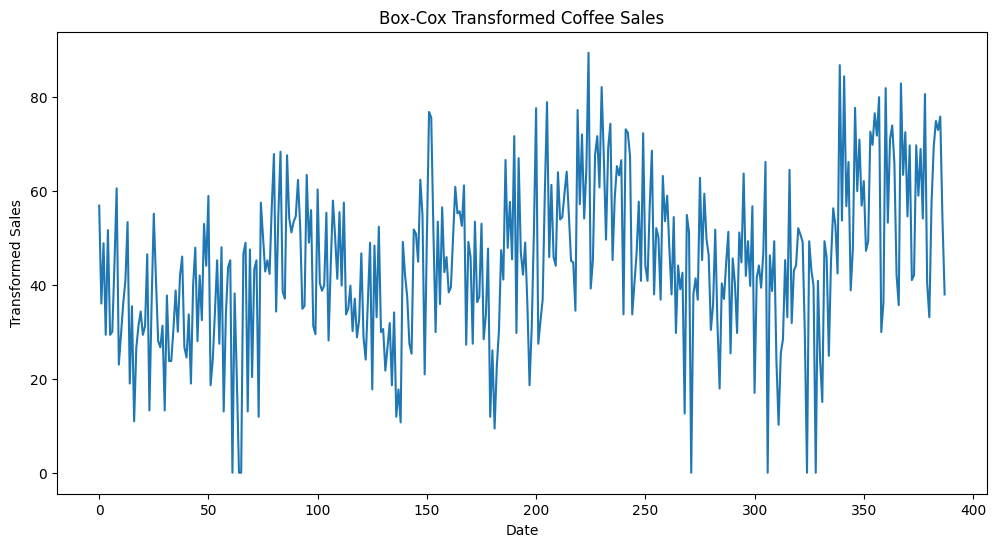

Lambda parameter for Box-Cox transformation: 0.5927155340473369


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('Coffe_sales.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Aggregate data, if necessary
daily_sales = data.resample('D').sum()

# Check for non-positive values
min_value = daily_sales['money'].min()
print(f'Minimum value in the data: {min_value}')

# If there are non-positive values, offset the data
if min_value <= 0:
    offset = abs(min_value) + 1  # Ensure all values are positive
    daily_sales['money'] += offset

# Apply Box-Cox transformation
boxcox_sales, lambda_param = stats.boxcox(daily_sales['money'])

# Visualize the Box-Cox transformed series
plt.figure(figsize=(12, 6))
plt.plot(boxcox_sales)
plt.title('Box-Cox Transformed Coffee Sales')
plt.xlabel('Date')
plt.ylabel('Transformed Sales')
plt.show()

# Print the lambda parameter used in the transformation
print(f'Lambda parameter for Box-Cox transformation: {lambda_param}')

**Smoothing Techniques**

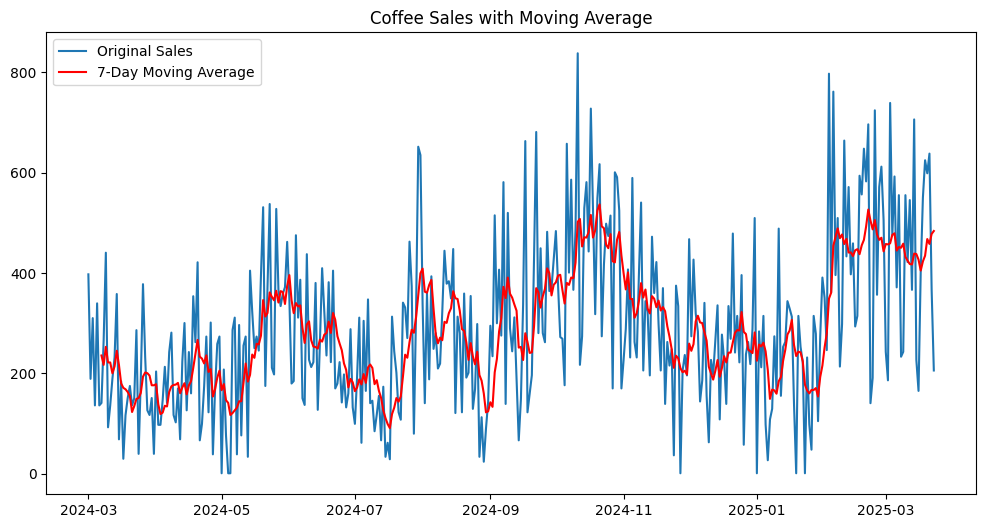

In [ ]:
# Apply moving average
window_size = 7  # 7-day moving average
moving_average_sales = daily_sales['money'].rolling(window=window_size).mean()

# Visualize the moving average
plt.figure(figsize=(12, 6))
plt.plot(daily_sales['money'], label='Original Sales')
plt.plot(moving_average_sales, label='7-Day Moving Average', color='red')
plt.title('Coffee Sales with Moving Average')
plt.legend()
plt.show()




**Log Transform (التحويل اللوغاريتمي)**

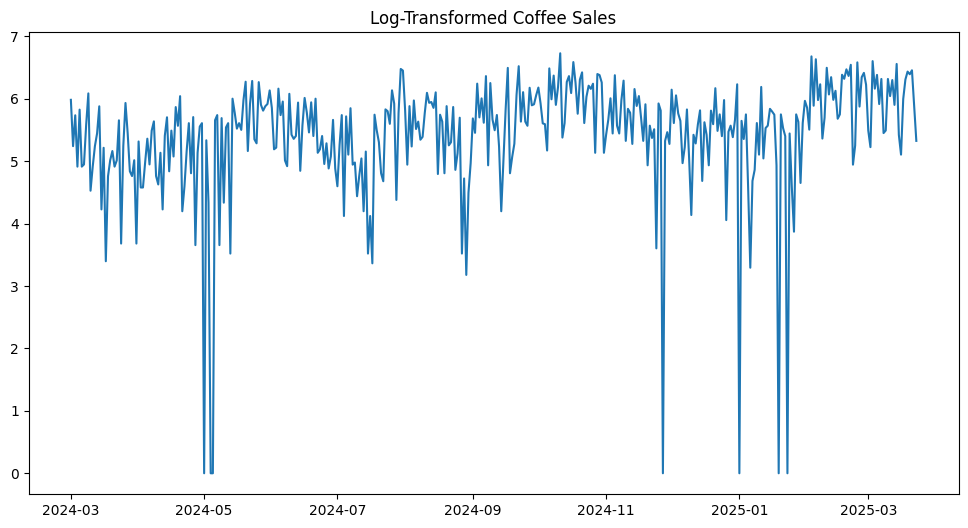

In [ ]:
# Apply log transformation
log_sales = np.log(daily_sales['money'])

# Visualize the log-transformed series
plt.figure(figsize=(12, 6))
plt.plot(log_sales)
plt.title('Log-Transformed Coffee Sales')
plt.show()

**جعل السلسلة ثابتة (Differencing)**

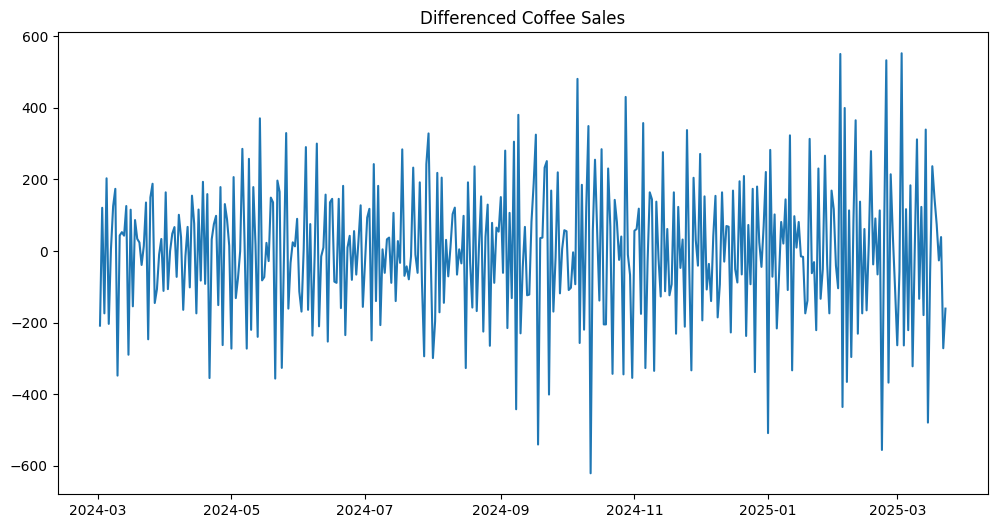

In [ ]:
import pandas as pd

# Load the data
data = pd.read_csv('Coffe_sales.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Aggregate data, if necessary
daily_sales = data.resample('D').sum()

# Perform differencing
differenced_sales = daily_sales['money'].diff().dropna()

# Visualize the differenced series
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(differenced_sales)
plt.title('Differenced Coffee Sales')
plt.show()

## طرق التحقق من الثبات (Checks for Stationarity)


### اختبار ديكي–فولر  (Augmented Dickey-Fuller Test)


In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('Coffe_sales.csv')

# Convert the Date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Set the Date as the index
data.set_index('Date', inplace=True)

# Aggregate the data (e.g., total money spent per day)
daily_sales = data.resample('D').sum()

# Perform the ADF test
result = adfuller(daily_sales['money'])

# Print the ADF test results
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -2.88552828633834
p-value: 0.04705692741174689
Critical Values:
   1%: -3.4476305904172904
   5%: -2.869155980820355
   10%: -2.570827146203181


- The Data is Statistical because in ADF test the P-value is 0.04 less than 0.05 .


- The Data dose not have White Noise .

## Train-Test Split

In [ ]:
import pandas as pd

# Load the data
data = pd.read_csv('Coffe_sales.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Aggregate data to get daily sales
daily_sales = data.resample('D').sum()

# Split the data into training and testing sets
# Ensure the test set has enough data for lagging
train_size = int(len(daily_sales) * 0.8)
# Make sure the test set has at least 2 data points for persistence model
if len(daily_sales) - train_size < 2:
    train_size = len(daily_sales) - 2
train_data, test_data = daily_sales['money'][0:train_size], daily_sales['money'][train_size:]

print('Training set size:', len(train_data))
print('Testing set size:', len(test_data))

Training set size: 310
Testing set size: 78


**Multiple Train-Test Splits**

In [ ]:
# Determine the number of splits
n_splits = 5
print(f'Number of splits: {n_splits}')

Number of splits: 5


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Instantiate TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=n_splits)

# Generate train and test indices for each split
splits = list(tscv.split(daily_sales))

print(f'Generated {len(splits)} splits.')

Generated 5 splits.


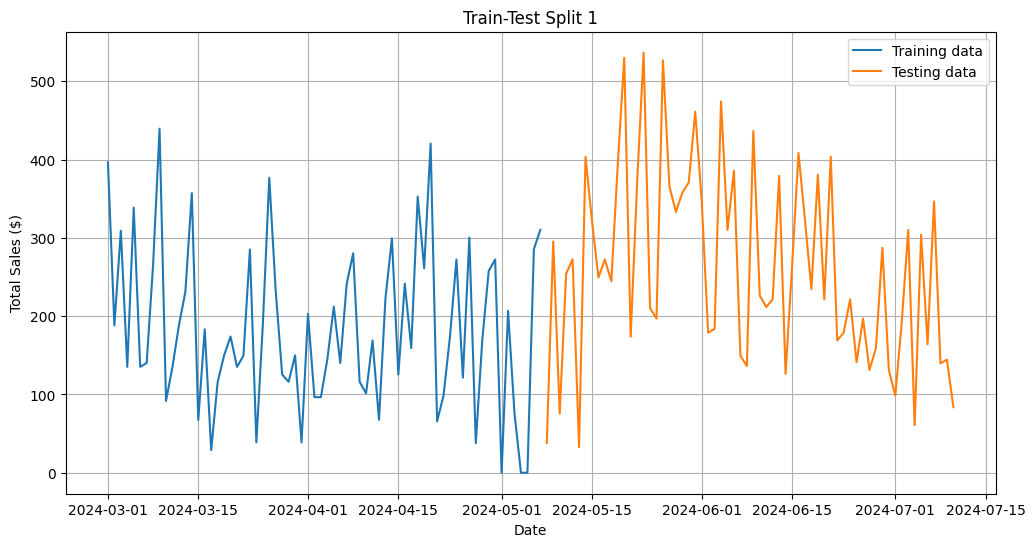

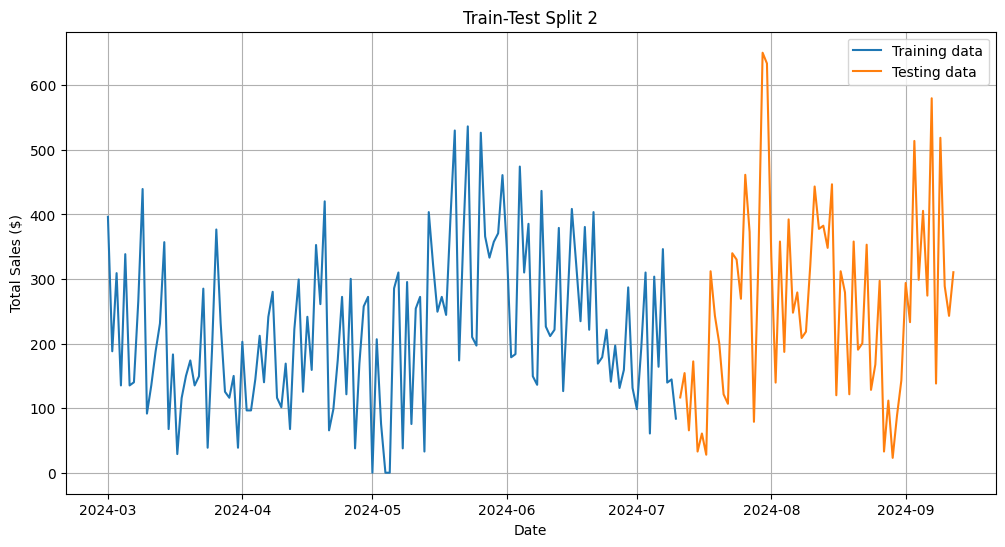

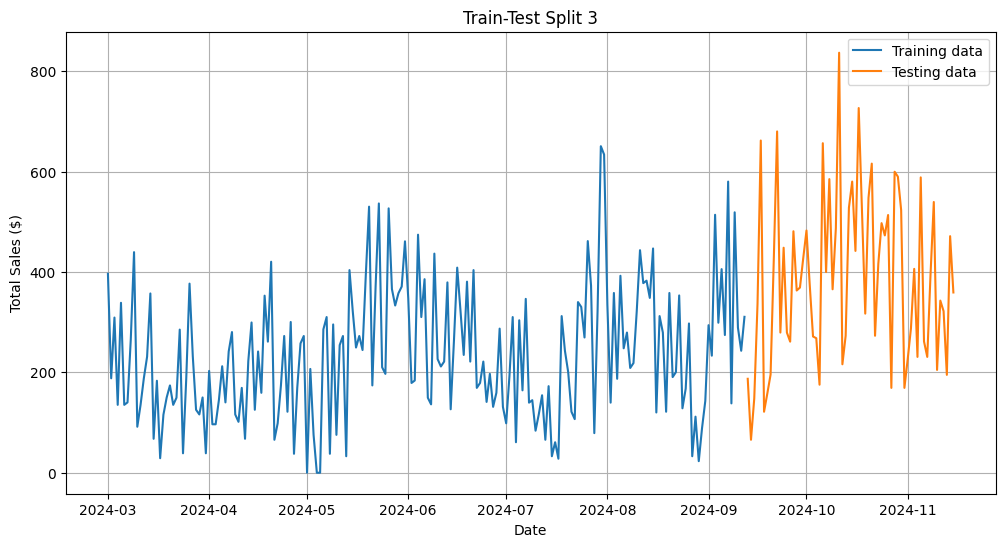

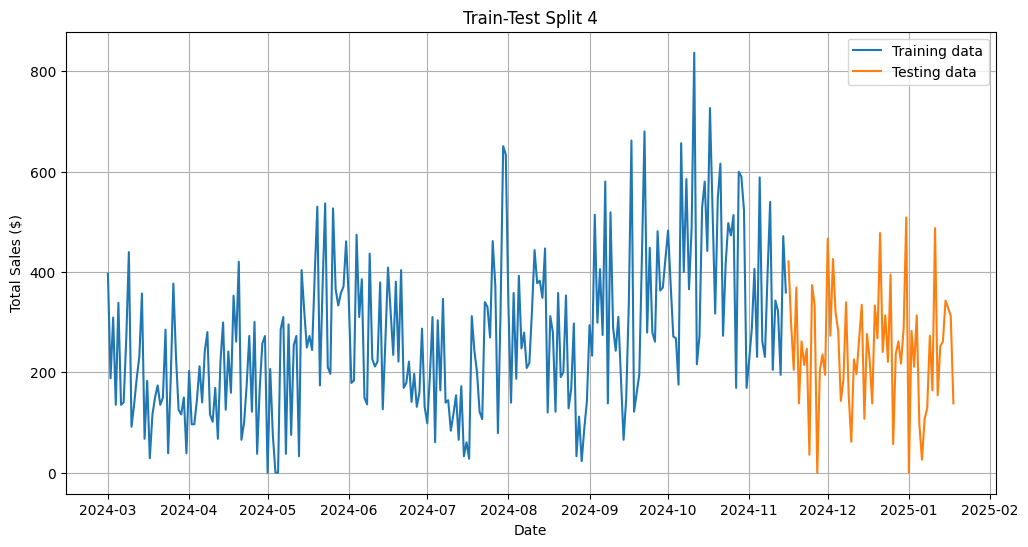

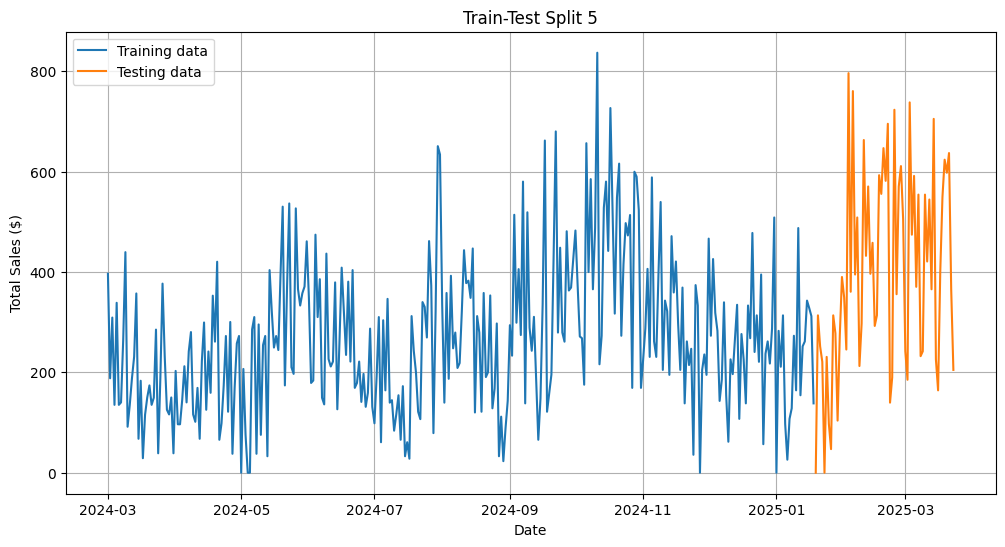

In [ ]:
# Loop through the splits and visualize each one
for i, (train_index, test_index) in enumerate(splits):
    plt.figure(figsize=(12, 6))
    plt.plot(daily_sales.iloc[train_index].index, daily_sales.iloc[train_index]['money'], label='Training data')
    plt.plot(daily_sales.iloc[test_index].index, daily_sales.iloc[test_index]['money'], label='Testing data')
    plt.title(f'Train-Test Split {i+1}')
    plt.xlabel('Date')
    plt.ylabel('Total Sales ($)')
    plt.legend()
    plt.grid()
    plt.show()

**Baseline**

Baseline RMSE: 230.78091641097015


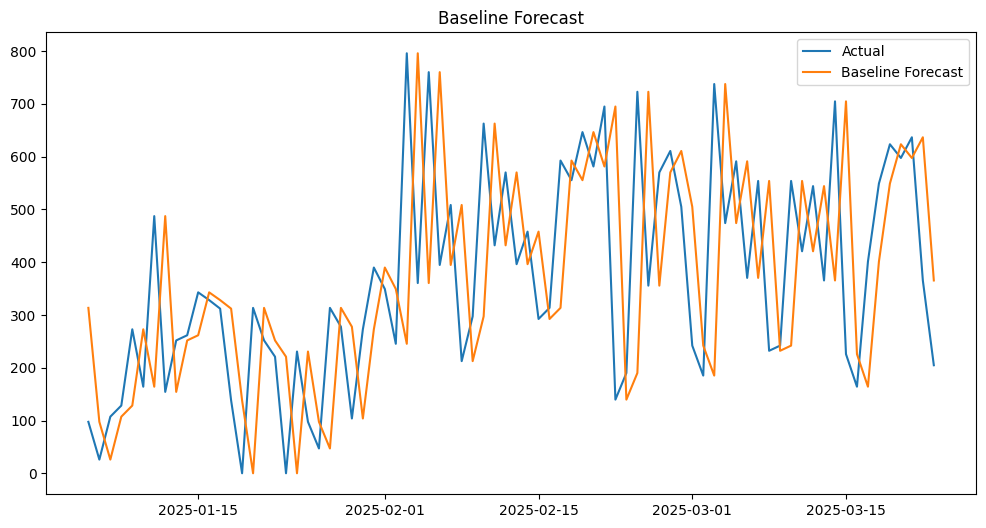

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# =====================
# ✅ Baseline (Persistence Model)
# =====================
# الفكرة: التنبؤ = آخر قيمة حقيقية شوهدت
# Use the defined train_data and test_data
baseline_pred = test_data.shift(1).fillna(train_data.iloc[-1])

# Define a function to calculate RMSE
def rmse(actual, predicted):
  return np.sqrt(mean_squared_error(actual, predicted))

baseline_rmse = rmse(test_data.values, baseline_pred.values)
print("Baseline RMSE:", baseline_rmse)

# رسم Baseline
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label="Actual")
plt.plot(test_data.index, baseline_pred.values, label="Baseline Forecast")
plt.title("Baseline Forecast")
plt.legend()
plt.show()

**Visualizing Residual Forecast Errors**

**ARMA Model**

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best ARMA(p,0,q) on differenced train: (2, 3) AIC: 3907.78
                               SARIMAX Results                                
Dep. Variable:                  money   No. Observations:                  309
Model:                 ARIMA(2, 0, 3)   Log Likelihood               -1946.892
Date:                Wed, 05 Nov 2025   AIC                           3907.784
Time:                        16:25:24   BIC                           3933.917
Sample:                    03-02-2024   HQIC                          3918.232
                         - 01-04-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1204      1.285      0.094      0.925      -2.399       2.639
ar.L1          1.3639      0.037     36.873      0.000       1.291      

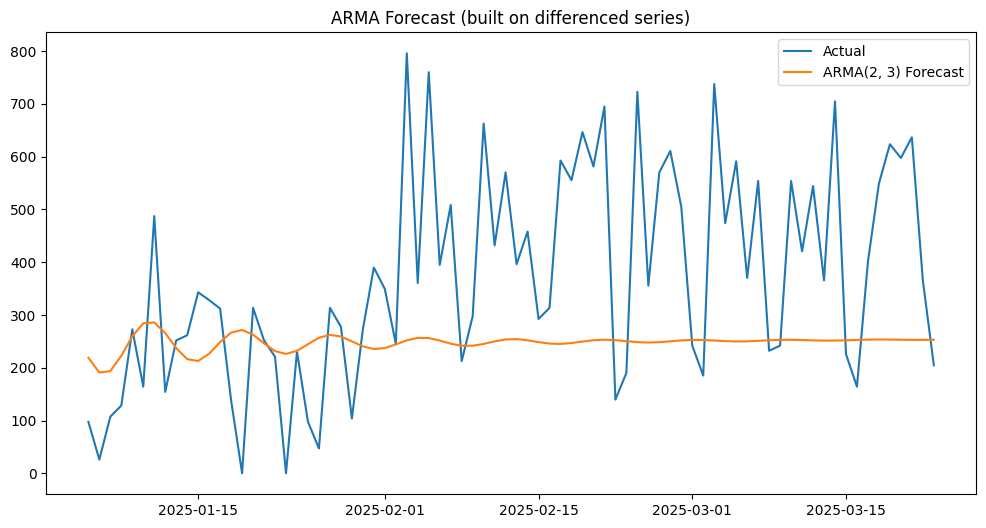

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Define a function to calculate RMSE
def rmse(actual, predicted):
  return np.sqrt(mean_squared_error(actual, predicted))

# --------- Prepare ARMA data: simple differencing ----------
train_diff = train_data.diff().dropna()

# Quick search for p,q (small to avoid complexity)
p_range = q_range = range(0,4)  # 0..3
best_aic, best_order = np.inf, None
arma_models = {}

for p in p_range:
    for q in q_range:
        if p==0 and q==0:
            continue
        try:
            m = ARIMA(train_diff, order=(p,0,q)).fit()
            arma_models[(p,q)] = m
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p,q)
        except Exception:
            pass

print("Best ARMA(p,0,q) on differenced train:", best_order, "AIC:", round(best_aic,2))
arma_best = arma_models[best_order]
print(arma_best.summary())

# --------- Predict on test data and revert differencing ----------
nsteps = len(test_data)
arma_diff_forecast = arma_best.get_forecast(steps=nsteps).predicted_mean

# Revert differencing: cumulative forecast + last actual value before test set
last_train_level = train_data.iloc[-1]
arma_level_forecast = last_train_level + arma_diff_forecast.cumsum()

print("ARMA RMSE:", rmse(test_data.values, arma_level_forecast.values))

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label="Actual")
plt.plot(test_data.index, arma_level_forecast.values, label=f"ARMA{best_order} Forecast")
plt.title("ARMA Forecast (built on differenced series)")
plt.legend()
plt.show()

**ARIMA Model**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/loc

Best ARIMA(p,d,q): (2, 1, 3) AIC: 3905.77
                               SARIMAX Results                                
Dep. Variable:                  money   No. Observations:                  310
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -1946.885
Date:                Wed, 05 Nov 2025   AIC                           3905.770
Time:                        16:25:36   BIC                           3928.170
Sample:                    03-01-2024   HQIC                          3914.726
                         - 01-04-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3624      0.037     36.726      0.000       1.290       1.435
ar.L2         -0.8802      0.041    -21.628      0.000      -0.960      -0.800
ma.L1     

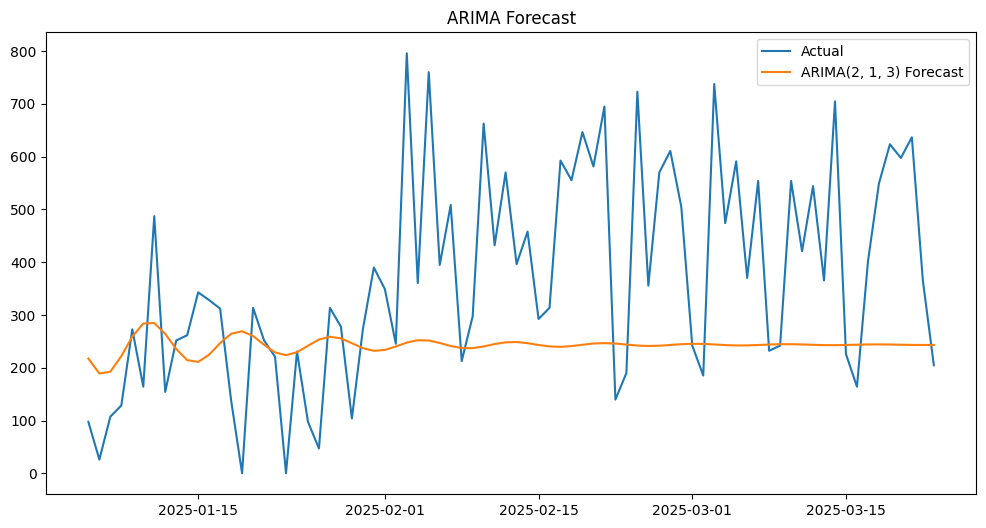

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import itertools

# Define a function to calculate RMSE
def rmse(actual, predicted):
  return np.sqrt(mean_squared_error(actual, predicted))

# --------- Quick search for (p,d,q) with d in {0,1} ----------
p = q = range(0,4)
d = [0,1]
best_aic, best_order = np.inf, None
arima_models = {}

for order in itertools.product(p, d, q):
    try:
        m = ARIMA(train_data, order=order).fit()
        arima_models[order] = m
        if m.aic < best_aic:
            best_aic, best_order = m.aic, order
    except Exception:
        pass

print("Best ARIMA(p,d,q):", best_order, "AIC:", round(best_aic,2))
arima_best = arima_models[best_order]
print(arima_best.summary())

# --------- Prediction ----------
nsteps = len(test_data)
arima_fc = arima_best.get_forecast(steps=nsteps)
arima_mean = arima_fc.predicted_mean

print("ARIMA RMSE:", rmse(test_data.values, arima_mean.values))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label="Actual")
plt.plot(test_data.index, arima_mean.values, label=f"ARIMA{best_order} Forecast")
plt.title("ARIMA Forecast")
plt.legend()
plt.show()

**SARIMA Model**

Best SARIMA (order)(seasonal): ((0, 1, 2), (0, 1, 1, 7)) AIC: 3717.9
                                      SARIMAX Results                                      
Dep. Variable:                               money   No. Observations:                  310
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 7)   Log Likelihood               -1854.950
Date:                             Wed, 05 Nov 2025   AIC                           3717.901
Time:                                     16:26:46   BIC                           3732.608
Sample:                                 03-01-2024   HQIC                          3723.792
                                      - 01-04-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8892      0.056    -

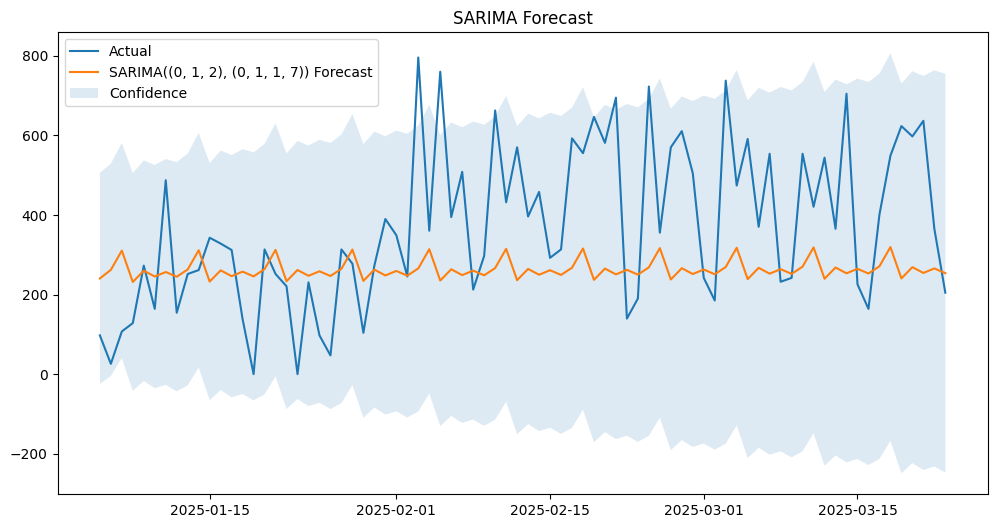

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import itertools
import warnings

warnings.filterwarnings("ignore")

# Define a function to calculate RMSE
def rmse(actual, predicted):
  return np.sqrt(mean_squared_error(actual, predicted))

# --------- Quick search for (p,d,q) and (P,D,Q,s) ----------
p = q = range(0,3)   # أصغر قليلاً لتسريع الوقت
d = [0,1]
P = Q = range(0,2)   # 0..1
D = [0,1]
s = 7     # Assuming weekly seasonality for daily data

best_aic, best_cfg = np.inf, None
sarima_models = {}

for order in itertools.product(p, d, q):
    for seas in itertools.product(P, D, Q, [s]):
        try:
            m = SARIMAX(train_data, order=order, seasonal_order=seas,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            sarima_models[(order, seas)] = m
            if m.aic < best_aic:
                best_aic, best_cfg = m.aic, (order, seas)
        except Exception:
            pass

print("Best SARIMA (order)(seasonal):", best_cfg, "AIC:", round(best_aic,2))
sarima_best = sarima_models[best_cfg]
print(sarima_best.summary())

# --------- تنبؤ ----------
nsteps = len(test_data)
sarima_fc = sarima_best.get_forecast(steps=nsteps)
sarima_mean = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int()

print("SARIMA RMSE:", rmse(test_data.values, sarima_mean.values))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label="Actual")
plt.plot(test_data.index, sarima_mean.values, label=f"SARIMA{best_cfg} Forecast")
plt.fill_between(test_data.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], alpha=0.15, label="Confidence")
plt.title("SARIMA Forecast")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

res = pd.DataFrame({
    "Model": ["Baseline", "ARMA", "ARIMA", "SARIMA"],
    "RMSE": [
        baseline_rmse,
        rmse(test_data.values, arma_level_forecast.values),
        rmse(test_data.values, arima_mean.values),
        rmse(test_data.values, sarima_mean.values)
    ],
    "AIC (best)": [
        None,  # Baseline غير مبني على نموذج احتمالي → ما له AIC
        float(arma_best.aic),
        float(arima_best.aic),
        float(sarima_best.aic)
    ],
    "Description": [
        "خط الأساس (Persistence)",
        "نموذج بدون ترند/موسمية",
        "يعالج الترند فقط",
        "يعالج الترند + الموسمية "
    ]
})

res = res.sort_values("RMSE", ascending=True)
res.style.hide(axis="index")

Model,RMSE,AIC (best),Description
SARIMA,226.278914,3717.900969,يعالج الترند + الموسمية
Baseline,230.780916,nan,خط الأساس (Persistence)
ARMA,231.046298,3907.783553,نموذج بدون ترند/موسمية
ARIMA,234.877611,3905.770046,يعالج الترند فقط


نماذج التعلم الذاتي

In [ ]:
# =====================
# (1) إعداد الميزات الإشرافية لسلاسل الزمن
# =====================
import numpy as np
import pandas as pd

def make_supervised(series: pd.Series, lags=12, roll_windows=(3, 6, 12)):
    """
    يحوّل السلسلة إلى إطار ميزات بإزاحات ومتوسطات متحركة.
    - series: سلسلة ذات فهرس زمني (Monthly)
    - lags: عدد الإزاحات الشهرية
    - roll_windows: نوافذ المتوسطات المتحركة
    """
    df = pd.DataFrame({'y': series.astype(float)}).copy()
    # لواحق زمنية
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = df['y'].shift(i)
    # ميزات متحركة
    for w in roll_windows:
        df[f'roll_mean_{w}'] = df['y'].shift(1).rolling(window=w).mean()
        df[f'roll_std_{w}']  = df['y'].shift(1).rolling(window=w).std()
    # إسقاط القيم المفقودة بعد التحويل
    df = df.dropna()
    return df

# ملاحظة:
# نتوقع وجود السلسلة باسم `series` (Electric_Production) من الخلايا السابقة في الدفتر.
assert 'series' in globals(), "السلسلة الزمنية `series` غير موجودة. شغّل الخلايا السابقة قبل تنفيذ هذا القسم."
supervised = make_supervised(series, lags=12, roll_windows=(3,6,12))

# تقسيم Train/Test — نفس الفكرة: آخر 24 شهرًا اختبارًا (يمكن تعديلها وفق ما استُخدم سابقًا)
test_horizon = 24 if len(supervised) > 200 else max(12, len(supervised)//5)
train_df = supervised.iloc[:-test_horizon].copy()
test_df  = supervised.iloc[-test_horizon:].copy()

X_train, y_train = train_df.drop(columns=['y']), train_df['y']
X_test,  y_test  = test_df.drop(columns=['y']),  test_df['y']

X_train.shape, X_test.shape

((964, 18), (24, 18))

In [ ]:
# =====================
# (2) نمذجة Gradient Boosting
# =====================
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

# تأكد من أن X_train و y_train و X_test و y_test تم إعدادها من الكود السابق
gbr = GradientBoostingRegressor(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))

print(f"GBR MAE:  {mae:.3f}")
print(f"GBR RMSE: {rmse:.3f}")

# حفظ النتائج في قاموس لاستخدام لاحق
ml_result = {
    'Model': 'GradientBoosting',
    'RMSE': rmse,
    'AIC (best)': None,
    'Description': 'تعلم آلي مع ميزات إزاحة ومتوسطات متحركة'
}

GBR MAE:  0.906
GBR RMSE: 1.158


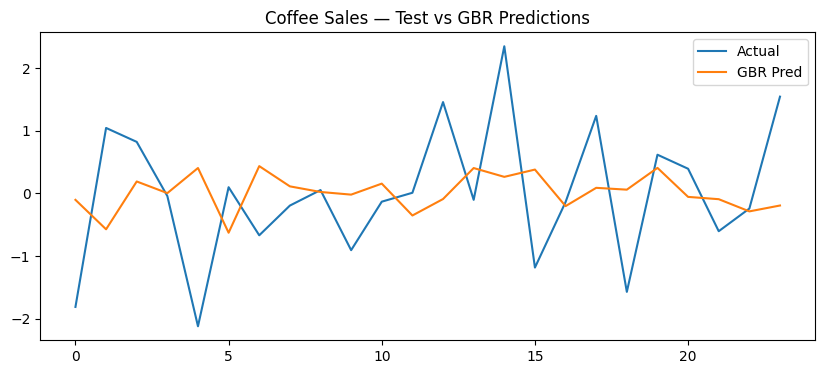

In [ ]:
# =====================
# (3) رسم مقارنة على فترة الاختبار
# =====================
import matplotlib.pyplot as plt
import pandas as pd

# تأكد من أن y_test و y_pred تم إعدادهما من الكود السابق
ax = y_test.reset_index(drop=True).plot(figsize=(10, 4), label='Actual')
pd.Series(y_pred).reset_index(drop=True).plot(ax=ax, label='GBR Pred')
plt.title('Coffee Sales — Test vs GBR Predictions')
plt.legend()
plt.show()

In [ ]:
# =====================
# (4) دمج نتيجة التعلم الآلي مع جدول النتائج السابق
# =====================
import pandas as pd

if 'res' in globals() and isinstance(res, pd.DataFrame):
    # توحيد الأعمدة (إن اختلفت)
    expected_cols = ['Model', 'RMSE', 'AIC (best)', 'Description']
    for col in expected_cols:
        if col not in res.columns:
            res[col] = None
    # إضافة صف جديد
    res = pd.concat([res, pd.DataFrame([ml_result])], ignore_index=True)
    # إعادة ترتيب وفرز
    res = res[expected_cols]
    res = res.sort_values('RMSE', ascending=True, na_position='last')
else:
    # إنشاء جدول نتائج جديد إن لم يكن موجودًا
    res = pd.DataFrame([ml_result], columns=['Model', 'RMSE', 'AIC (best)', 'Description'])

# عرض النتائج
display(res)

,Model,RMSE,AIC (best),Description
4,GradientBoosting,1.157574,NaN,تعلم آلي مع ميزات إزاحة ومتوسطات متحركة
0,SARIMA,226.278914,3717.900969,يعالج الترند + الموسمية
1,Baseline,230.780916,NaN,خط الأساس (Persistence)
2,ARMA,231.046298,3907.783553,نموذج بدون ترند/موسمية
3,ARIMA,234.877611,3905.770046,يعالج الترند فقط


**حزمة نماذج ML إضافية (RandomForest, XGBoost, LightGBM)**

In [ ]:
# =====================
# (0) تهيئة البيانات الإشرافية - أفق اختبار 12 شهر
# =====================
import numpy as np
import pandas as pd

assert 'series' in globals(), "السلسلة الزمنية `series` غير موجودة. شغّل الخلايا السابقة أولاً."

def make_supervised(series: pd.Series, lags=12, roll_windows=(3, 6, 12)):
    df = pd.DataFrame({'y': series.astype(float)}).copy()
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = df['y'].shift(i)
    for w in roll_windows:
        df[f'roll_mean_{w}'] = df['y'].shift(1).rolling(window=w).mean()
        df[f'roll_std_{w}']  = df['y'].shift(1).rolling(window=w).std()
    return df.dropna()

supervised = make_supervised(series, lags=12, roll_windows=(3, 6, 12))

# تقسيم بتثبيت أفق اختبار = 12
test_horizon = 12
train_df = supervised.iloc[:-test_horizon].copy()
test_df  = supervised.iloc[-test_horizon:].copy()
X_train, y_train = train_df.drop(columns=['y']), train_df['y']
X_test,  y_test  = test_df.drop(columns=['y']),  test_df['y']

X_train.shape, X_test.shape

((976, 18), (12, 18))

In [ ]:
# دوال مساعدة للتقييم والرسم
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

def evaluate_and_plot(model_name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} MAE:  {mae:.3f}")
    print(f"{model_name} RMSE: {rmse:.3f}")

    # رسم
    plt.figure(figsize=(10, 4))
    pd.Series(y_true.values, index=range(len(y_true))).plot(label='Actual')
    pd.Series(y_pred, index=range(len(y_true))).plot(label=f'{model_name} Pred')
    plt.title(f'Coffe Sales — Test vs {model_name} Predictions')
    plt.legend()
    plt.show()

    # إرجاع قاموس نتيجة
    return {
        'Model': model_name,
        'RMSE': rmse,
        'AIC (best)': None,
        'Description': f'{model_name} — تعلم آلي بميزات إزاحة/متوسطات متحركة'
    }

RandomForest MAE:  0.918
RandomForest RMSE: 1.119


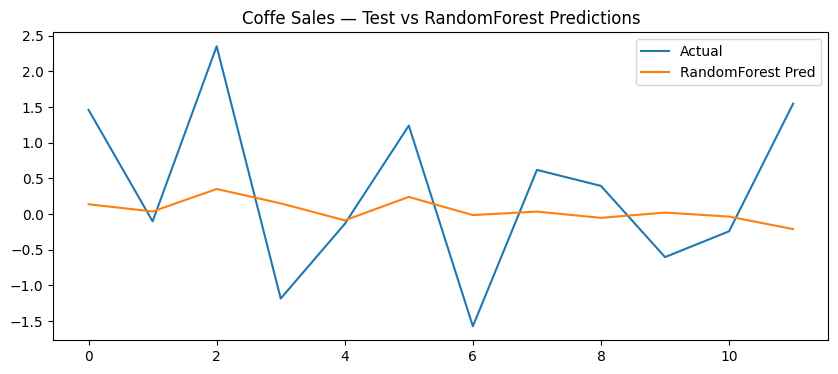

In [ ]:
# =====================
# (1) Random Forest Regressor
# =====================
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# استخدام الدالة للتقييم والرسم
rf_result = evaluate_and_plot('RandomForest', y_test, rf_pred)

XGBoost MAE:  0.914
XGBoost RMSE: 1.118


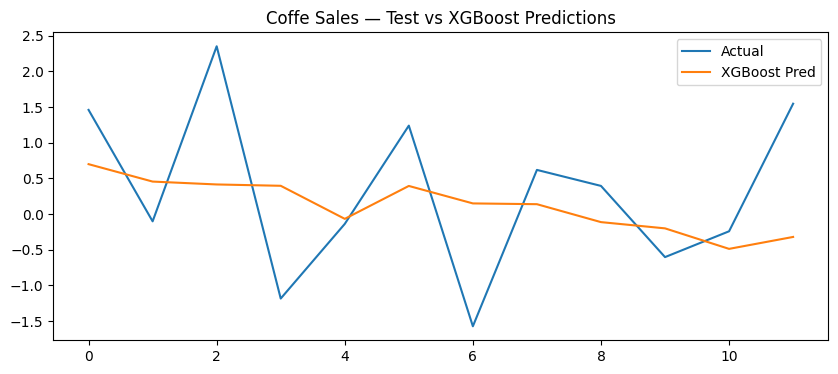

In [ ]:
# =====================
# (2) XGBoost Regressor
# =====================
xgb_result = None
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(
        n_estimators=800,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        tree_method='hist'  # أسرع عامةً
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)

    # استخدام الدالة للتقييم والرسم
    xgb_result = evaluate_and_plot('XGBoost', y_test, xgb_pred)
except Exception as e:
    print("تعذّر استخدام XGBoost:", e)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000419 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 976, number of used features: 18
[LightGBM] [Info] Start training from score -0.015864
LightGBM MAE:  0.944
LightGBM RMSE: 1.133


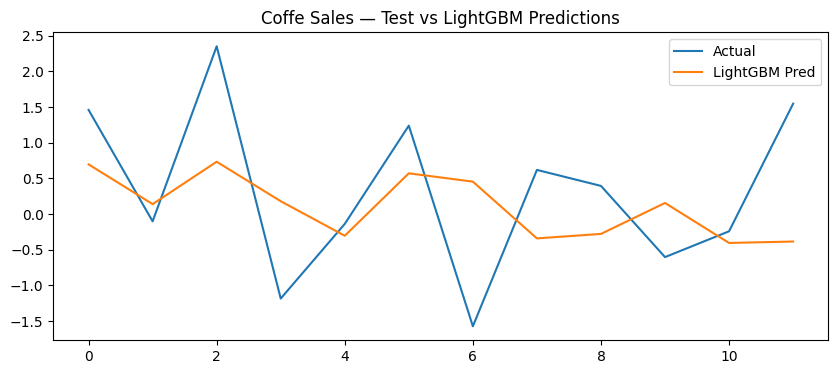

In [ ]:
# =====================
# (3) LightGBM Regressor
# =====================
lgbm_result = None
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(
        n_estimators=800,
        max_depth=-1,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
    lgbm.fit(X_train, y_train)
    lgbm_pred = lgbm.predict(X_test)

    # استخدام الدالة للتقييم والرسم
    lgbm_result = evaluate_and_plot('LightGBM', y_test, lgbm_pred)
except Exception as e:
    print("تعذّر استخدام LightGBM:", e)

In [ ]:
# =====================
# (4) دمج النتائج في جدول res إن وُجد + إضافة GradientBoosting إن كانت نتيجته محفوظة
# =====================
import pandas as pd

results = []
# من الخلايا السابقة في هذا الدفتر قد يكون لدينا ml_result (GradientBoosting)
if 'ml_result' in globals():
    results.append(ml_result)
# النماذج الجديدة
if 'rf_result' in globals() and rf_result is not None:
    results.append(rf_result)
if 'xgb_result' in globals() and xgb_result is not None:
    results.append(xgb_result)
if 'lgbm_result' in globals() and lgbm_result is not None:
    results.append(lgbm_result)

new_df = pd.DataFrame(results, columns=['Model','RMSE','AIC (best)','Description'])

if 'res' in globals() and isinstance(res, pd.DataFrame):
    # تأكّد من الأعمدة الأساسية
    expected_cols = ['Model', 'RMSE', 'AIC (best)', 'Description']
    for c in expected_cols:
        if c not in res.columns:
            res[c] = None
    res = pd.concat([res[expected_cols], new_df], ignore_index=True)
else:
    res = new_df.copy()

res = res.sort_values('RMSE', ascending=True, na_position='last').reset_index(drop=True)

print("📊 مقارنة النماذج (الأفضل = أقل RMSE):")
display(res)


📊 مقارنة النماذج (الأفضل = أقل RMSE):


,Model,RMSE,AIC (best),Description
0,XGBoost,1.118316,NaN,XGBoost — تعلم آلي بميزات إزاحة/متوسطات متحركة
1,RandomForest,1.119105,NaN,RandomForest — تعلم آلي بميزات إزاحة/متوسطات م...
2,LightGBM,1.132793,NaN,LightGBM — تعلم آلي بميزات إزاحة/متوسطات متحركة
3,GradientBoosting,1.157574,NaN,تعلم آلي مع ميزات إزاحة ومتوسطات متحركة
4,GradientBoosting,1.157574,NaN,تعلم آلي مع ميزات إزاحة ومتوسطات متحركة
5,SARIMA,226.278914,3717.900969,يعالج الترند + الموسمية
6,Baseline,230.780916,NaN,خط الأساس (Persistence)
7,ARMA,231.046298,3907.783553,نموذج بدون ترند/موسمية
8,ARIMA,234.877611,3905.770046,يعالج الترند فقط


**ML Seasonal Boost: LightGBM / XGBoost يتحدّى SARIMA**

In [ ]:
# =====================
# (A) استنتاج أفق الاختبار من قسم SARIMA
# =====================
import numpy as np, pandas as pd, types, inspect

assert 'series' in globals(), "السلسلة `series` غير معرّفة. شغّل خلايا التحضير أولاً."

def _len_if(v):
    try:
        return len(v)
    except Exception:
        return None

test_horizon = None
candidates = []

# 1) متغير test إن كان مُستخدمًا في أقسام سابقة
if 'test' in globals():
    candidates.append(('test', _len_if(globals()['test'])))

# 2) أسماء شائعة لنتائج SARIMA
for name in ['sarima_mean', 'sarima_forecast', 'sarima_pred', 'sarima_yhat']:
    if name in globals():
        candidates.append((name, _len_if(globals()[name])))

# 3) جدول المقارنة لا يحمل الطول، لكنه يدل أن هناك تقسيمًا قد تم
# إن لم نجد شيئًا، سنقترح 12 شهراً كخيار احتياطي.
length_guess = None
for k, v in candidates:
    if isinstance(v, (int, np.integer)) and v > 0:
        length_guess = v
        break

test_horizon = int(length_guess) if length_guess else 12
print("🧭 Inferred SARIMA test horizon =", test_horizon)


🧭 Inferred SARIMA test horizon = 78


In [ ]:
# =====================
# (B) هندسة ميزات موسمية متقدمة
# =====================
import numpy as np, pandas as pd

def make_seasonal_supervised(series: pd.Series, lags=(1,2,3,6,12,24), add_diff12=True,
                             add_trend=True, add_cyclical=True, add_month_dummies=False):
    s = pd.Series(series.astype(float).values, index=pd.to_datetime(series.index))
    df = pd.DataFrame({'y': s})

    # Lags
    for l in lags:
        df[f'lag_{l}'] = s.shift(l)

    # Seasonal differencing
    if add_diff12:
        df['diff_12'] = s - s.shift(12)

    # Trend features
    if add_trend:
        t = np.arange(len(s), dtype=float)
        df['t'] = t
        df['t2'] = t**2

    # Month-based features
    if add_cyclical or add_month_dummies:
        months = df.index.month
        if add_cyclical:
            df['m_sin'] = np.sin(2*np.pi*months/12.0)
            df['m_cos'] = np.cos(2*np.pi*months/12.0)
        if add_month_dummies:
            dummies = pd.get_dummies(months, prefix='m', drop_first=True)
            df = pd.concat([df, dummies], axis=1)

    df = df.dropna()
    return df

supervised_adv = make_seasonal_supervised(series, lags=(1,2,3,6,12,24),
                                          add_diff12=True, add_trend=True,
                                          add_cyclical=True, add_month_dummies=False)

# استخدام نفس أفق SARIMA الذي استنتجناه
train_df = supervised_adv.iloc[:-test_horizon].copy()
test_df  = supervised_adv.iloc[-test_horizon:].copy()
X_train, y_train = train_df.drop(columns=['y']), train_df['y']
X_test,  y_test  = test_df.drop(columns=['y']),  test_df['y']

X_train.shape, X_test.shape, X_train.columns[:8]

((898, 11),
 (78, 11),
 Index(['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'diff_12', 't'], dtype='object'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 898, number of used features: 9
[LightGBM] [Info] Start training from score -0.004195
LightGBM (seasonal boost) MAE:  0.0866
LightGBM (seasonal boost) RMSE: 0.1149


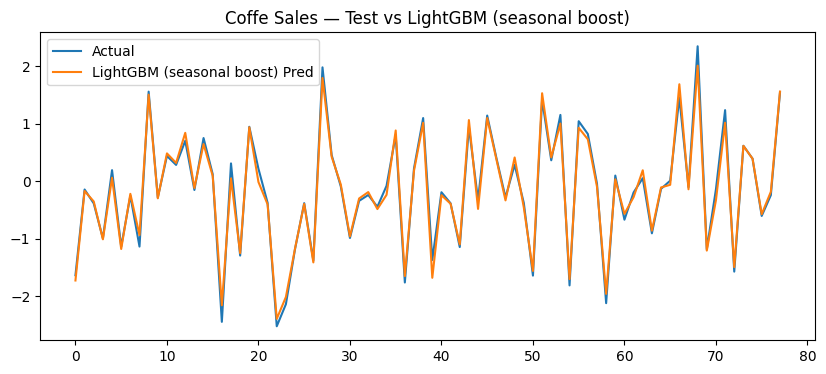

XGBoost (seasonal boost) MAE:  0.0866
XGBoost (seasonal boost) RMSE: 0.1177


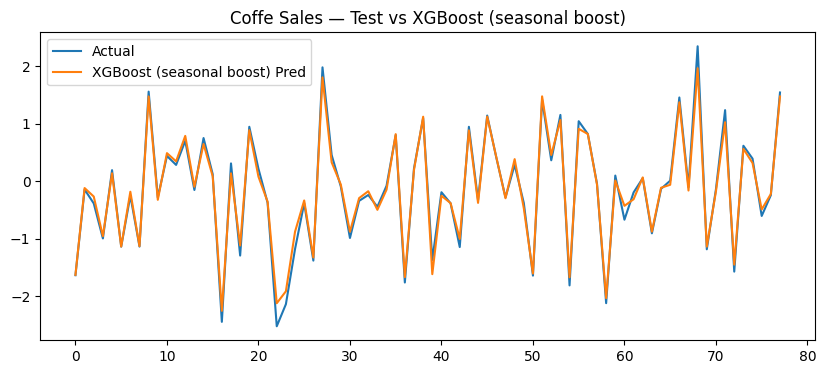

In [ ]:
# =====================
# (C) تدريب LightGBM / XGBoost مع إعدادات محسّنة
# =====================
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

def evaluate_and_plot(model_name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} MAE:  {mae:.4f}")
    print(f"{model_name} RMSE: {rmse:.4f}")
    plt.figure(figsize=(10,4))
    pd.Series(y_true.values, index=range(len(y_true))).plot(label='Actual')
    pd.Series(y_pred, index=range(len(y_true))).plot(label=f'{model_name} Pred')
    plt.title(f'Coffe Sales — Test vs {model_name}')
    plt.legend()
    plt.show()
    return {'Model': model_name, 'RMSE': rmse, 'AIC (best)': None,
            'Description': f'{model_name} — Seasonal features (lags,diff12,cyclical,trend)'}

lgbm_result2 = None
xgb_result2  = None

# LightGBM
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        min_child_samples=5,
        random_state=42,
        n_jobs=-1
    )
    lgbm.fit(X_train, y_train)
    lgbm_pred = lgbm.predict(X_test)
    lgbm_result2 = evaluate_and_plot('LightGBM (seasonal boost)', y_test, lgbm_pred)
except Exception as e:
    print("LightGBM غير متاح:", e)

# XGBoost
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(
        n_estimators=1400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        random_state=42,
        tree_method='hist'
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    xgb_result2 = evaluate_and_plot('XGBoost (seasonal boost)', y_test, xgb_pred)
except Exception as e:
    print("XGBoost غير متاح:", e)


In [ ]:
# =====================
# (D) دمج النتائج وإزالة التكرارات وعرض الجدول النهائي
# =====================
import pandas as pd

new_rows = []
if 'lgbm_result2' in globals() and lgbm_result2 is not None:
    new_rows.append(lgbm_result2)
if 'xgb_result2' in globals() and xgb_result2 is not None:
    new_rows.append(xgb_result2)

new_df = pd.DataFrame(new_rows, columns=['Model','RMSE','AIC (best)','Description'])

# لو كانت هناك نتائج سابقة (res) أدمجها
if 'res' in globals() and isinstance(res, pd.DataFrame):
    expected_cols = ['Model','RMSE','AIC (best)','Description']
    for c in expected_cols:
        if c not in res.columns:
            res[c] = None
    res_all = pd.concat([res[expected_cols], new_df], ignore_index=True)
else:
    res_all = new_df.copy()

# تنظيف التكرار عبر الاحتفاظ بأفضل RMSE لكل Model
res_all = res_all.sort_values('RMSE', ascending=True, na_position='last')
res_best = res_all.groupby('Model', as_index=False).first()
res_best = res_best.sort_values('RMSE', ascending=True, na_position='last').reset_index(drop=True)

print("📊 مقارنة نهائية بعد Seasonal Boost (الأفضل = أقل RMSE):")
display(res_best)


📊 مقارنة نهائية بعد Seasonal Boost (الأفضل = أقل RMSE):


,Model,RMSE,AIC (best),Description
0,LightGBM (seasonal boost),0.114865,NaN,LightGBM (seasonal boost) — Seasonal features ...
1,XGBoost (seasonal boost),0.117678,NaN,XGBoost (seasonal boost) — Seasonal features (...
2,XGBoost,1.118316,NaN,XGBoost — تعلم آلي بميزات إزاحة/متوسطات متحركة
3,RandomForest,1.119105,NaN,RandomForest — تعلم آلي بميزات إزاحة/متوسطات م...
4,LightGBM,1.132793,NaN,LightGBM — تعلم آلي بميزات إزاحة/متوسطات متحركة
5,GradientBoosting,1.157574,NaN,تعلم آلي مع ميزات إزاحة ومتوسطات متحركة
6,SARIMA,226.278914,3717.900969,يعالج الترند + الموسمية
7,Baseline,230.780916,NaN,خط الأساس (Persistence)
8,ARMA,231.046298,3907.783553,نموذج بدون ترند/موسمية
9,ARIMA,234.877611,3905.770046,يعالج الترند فقط
